In [99]:
!pip3  install numpy scipy matplotlib qiskit

In [101]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import random
import copy
import json
import math
import pickle
from fractions import Fraction
from decimal import Decimal

from itertools import permutations

from qiskit import QuantumCircuit, Aer
from qiskit.quantum_info import Statevector
from qiskit.compiler import transpile
from qiskit.tools.visualization import plot_histogram
from qiskit.circuit.library.standard_gates import SwapGate, PhaseGate
from qiskit.circuit.library import QFT

from qiskit.algorithms import EstimationProblem, AmplitudeEstimation
from qiskit.primitives import Sampler



from binary_optimizer import *


%load_ext autoreload
%autoreload 2


ModuleNotFoundError: No module named 'qiskit.tools'

# Single scenario, $\xi = \{010101...\}$ n=[2,17]

In [83]:
with open("binprob_data/run_record_linear_alltoall.json", 'r') as json_file:
    run_record_linear = json.load(json_file)
    run_record_linear = {(int(s.split()[0][1:-1]), int(s.split()[1][:-1])):val for s,val in run_record_linear.items()}
    run_record_linear = {key0: 
                                   {key1: {int(x):o for x,o in value1.items()} 
                                    for key1,value1 in value0.items()} 
                                   for key0,value0 in run_record_linear.items()}
    
with open("binprob_data/run_record_square_alltoall.json", 'r') as json_file:
    run_record_square = json.load(json_file)
    run_record_square = {(int(s.split()[0][1:-1]), int(s.split()[1][:-1])):val for s,val in run_record_square.items()}
    run_record_square = {key0: 
                                   {key1: {int(x):o for x,o in value1.items()} 
                                    for key1,value1 in value0.items()} 
                                   for key0,value0 in run_record_square.items()}
    
with open("binprob_data/run_record_exp_alltoall.json", 'r') as json_file:
    run_record_exp = json.load(json_file)
    run_record_exp = {(int(s.split()[0][1:-1]), int(s.split()[1][:-1])):val for s,val in run_record_exp.items()}
    run_record_exp = {key0: 
                                   {key1: {int(x):o for x,o in value1.items()} 
                                    for key1,value1 in value0.items()} 
                                   for key0,value0 in run_record_exp.items()}

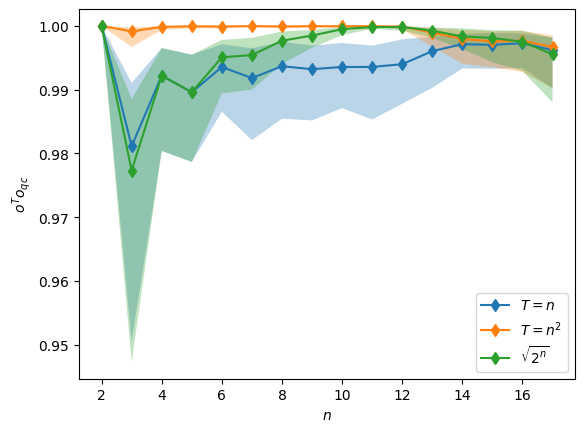

In [84]:
# combine linear and quadratic plot
nmin = 2
nmax = 18
samples = 30
xd = []
ydlinmeans = []
ydlinlower = []
ydlinupper = []
ydquadmeans = []
ydquadlower = []
ydquadupper = []
ydexpmeans = []
ydexplower = []
ydexpupper = []
for n in range(nmin,nmax):
    xd.append(n)
    ydlin = []
    ydquad = []
    ydexp = []
    for sample in range(samples):
        
        # linear
        results = run_record_linear[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qc_energy_surface']
        true_vec = []
        qc_vec = []
        for x in range(n+1):
            true_vec.append(true[x])
            qc_vec.append(qc[x])
        true_vec = np.array(true_vec)
        true_vec = true_vec[1:-1]
        true_vec /= np.linalg.norm(true_vec)
        qc_vec = np.array(qc_vec)
        qc_vec = qc_vec[1:-1]
        qc_vec /= np.linalg.norm(qc_vec)
        ydlin.append(true_vec.T @ qc_vec)
        
        # quadratic
        results = run_record_square[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qc_energy_surface']
        true_vec = []
        qc_vec = []
        for x in range(n+1):
            true_vec.append(true[x])
            qc_vec.append(qc[x])
        true_vec = np.array(true_vec)
        true_vec = true_vec[1:-1]
        true_vec /= np.linalg.norm(true_vec)
        qc_vec = np.array(qc_vec)
        qc_vec = qc_vec[1:-1]
        qc_vec /= np.linalg.norm(qc_vec)
        ydquad.append(true_vec.T @ qc_vec)
            
        # exp
        results = run_record_exp[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qc_energy_surface']
        true_vec = []
        qc_vec = []
        for x in range(n+1):
            true_vec.append(true[x])
            qc_vec.append(qc[x])
        true_vec = np.array(true_vec)
        true_vec = true_vec[1:-1]
        true_vec /= np.linalg.norm(true_vec)
        qc_vec = np.array(qc_vec)
        qc_vec = qc_vec[1:-1]
        qc_vec /= np.linalg.norm(qc_vec)
        ydexp.append(true_vec.T @ qc_vec)
        
    # process lin
    mlin = np.mean(ydlin)
    ydlinmeans.append(mlin)
    ydlinlower.append(mlin-np.min(ydlin))
    ydlinupper.append(np.max(ydlin)-mlin)
    # process quad
    mquad = np.mean(ydquad)
    ydquadmeans.append(mquad)
    ydquadlower.append(mquad-np.min(ydquad))
    ydquadupper.append(np.max(ydquad)-mquad)
    # process exp
    mexp = np.mean(ydexp)
    ydexpmeans.append(mexp)
    ydexplower.append(mexp-np.min(ydexp))
    ydexpupper.append(np.max(ydexp)-mexp)

plt.ylabel(r'$o^To_{qc}$')
plt.xlabel(r'$n$')
#plt.ylim([0.94, 1.001])
plt.fill_between(xd, np.array(ydlinmeans)-np.array(ydlinlower), np.array(ydlinmeans)+np.array(ydlinupper), alpha=.3)
plt.fill_between(xd, np.array(ydquadmeans)-np.array(ydquadlower), np.array(ydquadmeans)+np.array(ydquadupper), alpha=.3)
plt.fill_between(xd, np.array(ydexpmeans)-np.array(ydexplower), np.array(ydexpmeans)+np.array(ydexpupper), alpha=.3)
#plt.errorbar(xd,ydlinmeans,  [ydlinlower, ydlinupper], label=r'$T=n$')
#plt.errorbar(xd,ydquadmeans, [ydquadlower, ydquadupper], label=r'$T=n^2$')
#plt.errorbar(xd,ydexpmeans, [ydexplower, ydexpupper], label=r'$\sqrt{2^n}$')
plt.plot(xd,ydlinmeans, '-d', label=r'$T=n$')
plt.plot(xd,ydquadmeans, '-d', label=r'$T=n^2$')
plt.plot(xd,ydexpmeans, '-d', label=r'$\sqrt{2^n}$')
plt.legend(loc='lower right')

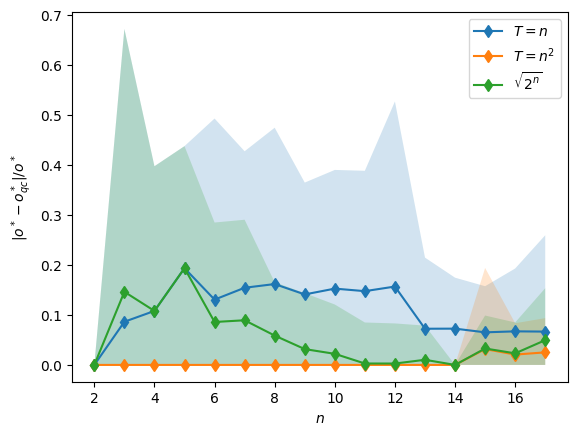

In [85]:
# get difference in answers
# combine linear and quadratic plot
nmin = 2
nmax = 18
samples = 30
xd = []
ydlinmeans = []
ydlinlower = []
ydlinupper = []
ydquadmeans = []
ydquadlower = []
ydquadupper = []
ydexpmeans = []
ydexplower = []
ydexpupper = []
for n in range(nmin,nmax):
    xd.append(n)
    ydlin = []
    ydquad = []
    ydexp = []
    for sample in range(samples):
        
        # linear
        results = run_record_linear[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qc_energy_surface']
        true_vec = []
        qc_vec = []
        for x in range(n+1):
            true_vec.append(true[x])
            qc_vec.append(qc[x])
        true_vec = true_vec[1:-1]
        qc_vec = qc_vec[1:-1]
        x_min = np.argmin(true_vec)#, key=true.get)
        x_qc = np.argmin(qc_vec,)#, key=qc.get)
        o_qc = true_vec[x_qc]
        ydlin.append(np.abs(true_vec[x_min]-o_qc)/true_vec[x_min])
        
        # quadratic
        results = run_record_square[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qc_energy_surface']
        true_vec = []
        qc_vec = []
        for x in range(n+1):
            true_vec.append(true[x])
            qc_vec.append(qc[x])
        true_vec = true_vec[1:-1]
        qc_vec = qc_vec[1:-1]
        x_min = np.argmin(true_vec)#, key=true.get)
        x_qc = np.argmin(qc_vec,)#, key=qc.get)
        o_qc = true_vec[x_qc]
        ydquad.append(np.abs(true_vec[x_min]-o_qc)/true_vec[x_min])
        #x_min = min(true, key=true.get)
        #x_qc = min(qc, key=qc.get)
        #o_qc = true[x_qc]
        #ydquad.append(np.abs(true[x_min]-o_qc)/true[x_min])
        
        # sqrt exponential
        results = run_record_exp[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qc_energy_surface']
        true_vec = []
        qc_vec = []
        for x in range(n+1):
            true_vec.append(true[x])
            qc_vec.append(qc[x])
        true_vec = true_vec[1:-1]
        qc_vec = qc_vec[1:-1]
        x_min = np.argmin(true_vec)#, key=true.get)
        x_qc = np.argmin(qc_vec,)#, key=qc.get)
        o_qc = true_vec[x_qc]
        ydexp.append(np.abs(true_vec[x_min]-o_qc)/true_vec[x_min])
    
    # process lin
    mlin = np.mean(ydlin)
    ydlinmeans.append(mlin)
    ydlinlower.append(mlin-np.min(ydlin))
    ydlinupper.append(np.max(ydlin)-mlin)
    
    # process quad
    mquad = np.mean(ydquad)
    ydquadmeans.append(mquad)
    ydquadlower.append(mquad-np.min(ydquad))
    ydquadupper.append(np.max(ydquad)-mquad)
    
    # process exp
    mexp = np.mean(ydexp)
    ydexpmeans.append(mexp)
    ydexplower.append(mexp-np.min(ydexp))
    ydexpupper.append(np.max(ydexp)-mexp)
    

#plt.ylim([0.9, 1.01])
plt.ylabel(r'$|o^*-o^*_{qc}|/o^*$')
plt.xlabel(r'$n$')
#plt.errorbar(xd, ydlinmeans,  [ydlinlower, ydlinupper], label=r'$T=n$')
#plt.errorbar(xd, ydquadmeans, [ydquadlower, ydquadupper], label=r'$T=n^2$')
#plt.errorbar(xd, ydexpmeans, [ydexplower, ydexpupper], label=r'$T=\sqrt{2^n}$')
plt.fill_between(xd, np.array(ydlinmeans)-np.array(ydlinlower), np.array(ydlinmeans)+np.array(ydlinupper), alpha=.2)
plt.plot(xd,ydlinmeans, '-d', label=r'$T=n$')

plt.fill_between(xd, np.array(ydquadmeans)-np.array(ydquadlower), np.array(ydquadmeans)+np.array(ydquadupper), alpha=.2)
plt.plot(xd,ydquadmeans, '-d', label=r'$T=n^2$')

plt.fill_between(xd, np.array(ydexpmeans)-np.array(ydexplower), np.array(ydexpmeans)+np.array(ydexpupper), alpha=.2)
plt.plot(xd,ydexpmeans, '-d', label=r'$\sqrt{2^n}$')
plt.legend()

# $\langle H\rangle$ with i.i.d. PDF and n=[2,10]

In [86]:
with open("binprob_data/run_record_pdf_linear.json", 'r') as json_file:
    run_record_pdf_linear = json.load(json_file)
    run_record_pdf_linear = {(int(s.split()[0][1:-1]), int(s.split()[1][:-1])):val for s,val in run_record_pdf_linear.items()}
    run_record_pdf_linear = {key0: 
                                   {key1: {int(x):o for x,o in value1.items()} 
                                    for key1,value1 in value0.items()} 
                                   for key0,value0 in run_record_pdf_linear.items()}
    
with open("binprob_data/run_record_pdf_square.json", 'r') as json_file:
    run_record_pdf_square = json.load(json_file)
    run_record_pdf_square = {(int(s.split()[0][1:-1]), int(s.split()[1][:-1])):val for s,val in run_record_pdf_square.items()}
    run_record_pdf_square = {key0: 
                                   {key1: {int(x):o for x,o in value1.items()} 
                                    for key1,value1 in value0.items()} 
                                   for key0,value0 in run_record_pdf_square.items()}

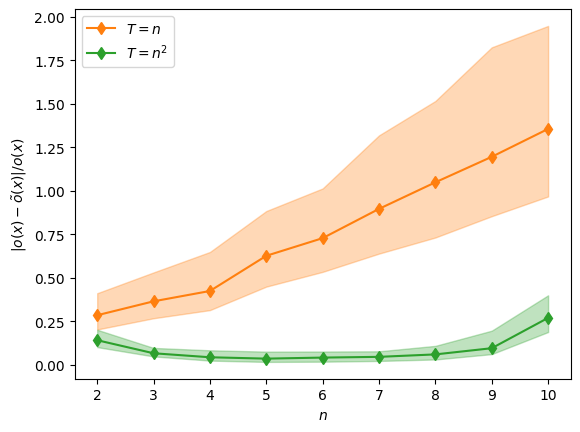

In [87]:
# combine linear and quadratic plot
nmin = 2
nmax = 11
samples = 30
xd = []
ydlinmeans = []
ydlinlower = []
ydlinupper = []
ydquadmeans = []
ydquadlower = []
ydquadupper = []
for n in range(nmin,nmax):
    xd.append(n)
    ydlin = []
    ydquad = []
    for sample in range(samples):
        
        # linear
        results = run_record_pdf_linear[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qc_energy_surface']
        true_vec = []
        qc_vec = []
        for x in range(n+1):
            true_vec.append(true[x])
            qc_vec.append(qc[x])
        true_vec = np.array(true_vec)
        #true_vec = true_vec[1:-1]
        #true_vec /= np.linalg.norm(true_vec)
        qc_vec = np.array(qc_vec)
        #qc_vec = qc_vec[1:-1]
        #qc_vec /= np.linalg.norm(qc_vec)
        #ydlin.append(true_vec.T @ qc_vec)
        ydlin.append(np.sum(np.abs(true_vec-qc_vec)/true_vec))
        #if ydlin[-1] > 1.8 or ydlin[-1] == 0:
        #    print('l', ydlin[-1], n, sample)
        
        # quadratic
        results = run_record_pdf_square[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qc_energy_surface']
        true_vec = []
        qc_vec = []
        for x in range(n+1):
            true_vec.append(true[x])
            qc_vec.append(qc[x])
        true_vec = np.array(true_vec)
        #true_vec = true_vec[1:-1]
        #true_vec /= np.linalg.norm(true_vec)
        qc_vec = np.array(qc_vec)
        #qc_vec = qc_vec[1:-1]
        #qc_vec /= np.linalg.norm(qc_vec)
        #ydquad.append(true_vec.T @ qc_vec)
        ydquad.append(np.sum(np.abs(true_vec-qc_vec)/true_vec))
        #if ydquad[-1] > 1.8 or ydquad[-1] < .20:
        #    print('q', ydquad[-1], n, sample)
        
    # process lin
    mlin = np.mean(ydlin)
    ydlinmeans.append(mlin)
    ydlinlower.append(mlin-np.min(ydlin))
    ydlinupper.append(np.max(ydlin)-mlin)
    # process quad
    mquad = np.mean(ydquad)
    ydquadmeans.append(mquad)
    ydquadlower.append(mquad-np.min(ydquad))
    ydquadupper.append(np.max(ydquad)-mquad)
    
fnrel_err_lin_mean = ydlinmeans
fnrel_err_lin_lower = ydlinlower
fnrel_err_lin_upper = ydlinupper
fnrel_err_quad_mean = ydquadmeans
fnrel_err_quad_lower = ydquadlower
fnrel_err_quad_upper = ydquadupper

plt.ylabel(r'$|o(x) - \tilde{o}(x)|/o(x)$')
plt.xlabel(r'$n$')
#plt.ylim([0.94, 1.001])
plt.fill_between(xd, np.array(ydlinmeans)-np.array(ydlinlower), np.array(ydlinmeans)+np.array(ydlinupper), alpha=.3, color='tab:orange')
plt.plot(xd,ydlinmeans, '-d', label=r'$T=n$', color='tab:orange')

plt.fill_between(xd, np.array(ydquadmeans)-np.array(ydquadlower), np.array(ydquadmeans)+np.array(ydquadupper), alpha=.3, color='tab:green')
plt.plot(xd,ydquadmeans, '-d', label=r'$T=n^2$', color='tab:green')

plt.legend(loc='upper left')

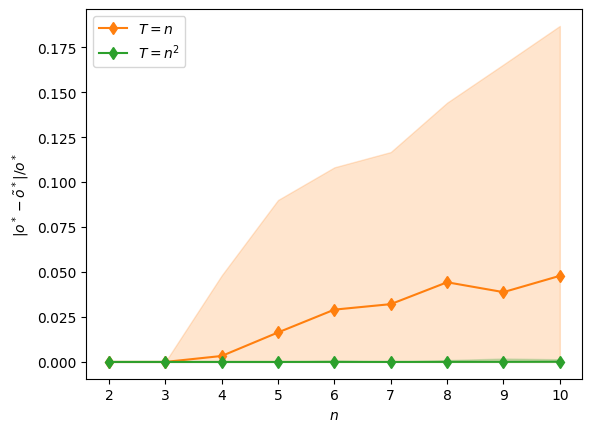

In [88]:
# get difference in answers
# combine linear and quadratic plot
nmin = 2
nmax = 11
samples = 30
xd = []
ydlinmeans = []
ydlinlower = []
ydlinupper = []
ydquadmeans = []
ydquadlower = []
ydquadupper = []
for n in range(nmin,nmax):
    xd.append(n)
    ydlin = []
    ydquad = []
    for sample in range(samples):
        
        # linear
        results = run_record_pdf_linear[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qc_energy_surface']
        true_vec = []
        qc_vec = []
        for x in range(n+1):
            true_vec.append(true[x])
            qc_vec.append(qc[x])
        true_vec = true_vec[1:-1]
        qc_vec = qc_vec[1:-1]
        x_min = np.argmin(true_vec)#, key=true.get)
        x_qc = np.argmin(qc_vec,)#, key=qc.get)
        o_qc = true_vec[x_qc]
        ydlin.append(np.abs(true_vec[x_min]-o_qc)/true_vec[x_min])
        
        # quadratic
        results = run_record_pdf_square[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qc_energy_surface']
        true_vec = []
        qc_vec = []
        for x in range(n+1):
            true_vec.append(true[x])
            qc_vec.append(qc[x])
        true_vec = true_vec[1:-1]
        qc_vec = qc_vec[1:-1]
        x_min = np.argmin(true_vec)#, key=true.get)
        x_qc = np.argmin(qc_vec,)#, key=qc.get)
        o_qc = true_vec[x_qc]
        ydquad.append(np.abs(true_vec[x_min]-o_qc)/true_vec[x_min])
    
    # process lin
    mlin = np.mean(ydlin)
    ydlinmeans.append(mlin)
    ydlinlower.append(mlin-np.min(ydlin))
    ydlinupper.append(np.max(ydlin)-mlin)
    
    # process quad
    mquad = np.mean(ydquad)
    ydquadmeans.append(mquad)
    ydquadlower.append(mquad-np.min(ydquad))
    ydquadupper.append(np.max(ydquad)-mquad)
    
orel_err_lin_mean = ydlinmeans
orel_err_lin_lower = ydlinlower
orel_err_lin_upper = ydlinupper
orel_err_quad_mean = ydquadmeans
orel_err_quad_lower = ydquadlower
orel_err_quad_upper = ydquadupper
    
#plt.ylim([0.9, 1.01])
plt.ylabel(r'$|o^*-\tilde{o}^*|/o^*$')
plt.xlabel(r'$n$')
#plt.errorbar(xd, ydlinmeans,  [ydlinlower, ydlinupper], label=r'$T=n$')
#plt.errorbar(xd, ydquadmeans, [ydquadlower, ydquadupper], label=r'$T=n^2$')
#plt.errorbar(xd, ydexpmeans, [ydexplower, ydexpupper], label=r'$T=\sqrt{2^n}$')
plt.fill_between(xd, np.array(ydlinmeans)-np.array(ydlinlower), np.array(ydlinmeans)+np.array(ydlinupper), alpha=.2, color='tab:orange')
plt.plot(xd,ydlinmeans, '-d', label=r'$T=n$', color='tab:orange')

plt.fill_between(xd, np.array(ydquadmeans)-np.array(ydquadlower), np.array(ydquadmeans)+np.array(ydquadupper), alpha=.2, color='tab:green')
plt.plot(xd,ydquadmeans, '-d', label=r'$T=n^2$', color='tab:green')

#plt.fill_between(xd, np.array(ydexpmeans)-np.array(ydexplower), np.array(ydexpmeans)+np.array(ydexpupper), alpha=.2)
#plt.plot(xd,ydexpmeans, '-d', label=r'$\sqrt{2^n}$')
plt.legend(loc='upper left')

1.6511903425763936


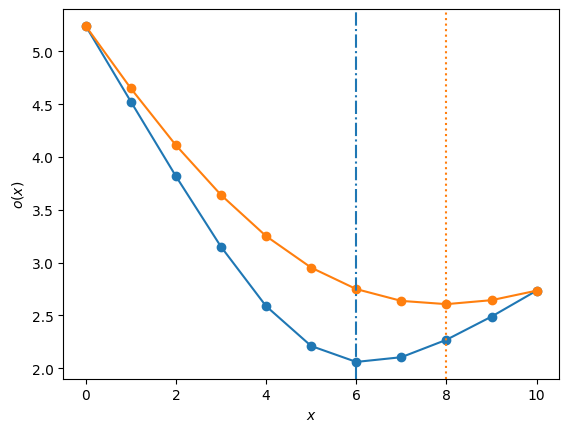

0.3324312995984793


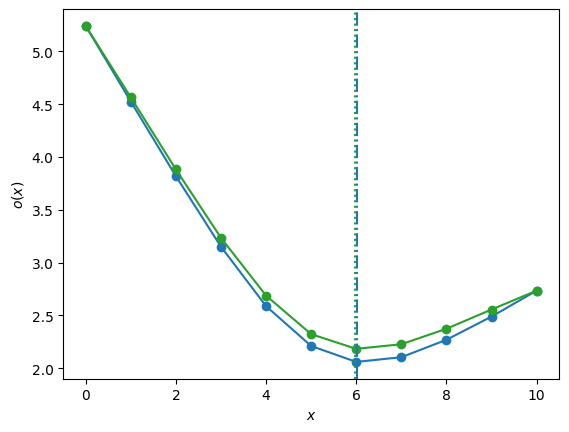

In [89]:
## Make plots of $o$
# n=10, sample=27  'bad'
# n=10, sample=29  'good'
si = 24

# bad line
n = 10
sample = si
results = run_record_pdf_linear[(n,sample)]
true = results['true_energy_surface']
qc = results['qc_energy_surface']
true_vec = []
qc_vec = []
for x in range(n+1):
    true_vec.append(true[x])
    qc_vec.append(qc[x])
bad_true_vec = np.array(true_vec)
bad_qc_vec = np.array(qc_vec)
print(np.sum(np.abs(bad_true_vec-bad_qc_vec)/bad_true_vec))
plt.ylabel(r'$o(x)$')
plt.xlabel(r'$x$')
plt.plot(true_vec, '-o')
plt.plot(qc_vec, '-o')
plt.axvline(np.argmin(true_vec), linestyle='-.')
plt.axvline(np.argmin(qc_vec), color='tab:orange', linestyle=':')
plt.show()

# good line
n = 10
sample = si
results = run_record_pdf_square[(n,sample)]
true = results['true_energy_surface']
qc = results['qc_energy_surface']
true_vec = []
qc_vec = []
for x in range(n+1):
    true_vec.append(true[x])
    qc_vec.append(qc[x])
good_true_vec = np.array(true_vec)
good_qc_vec = np.array(qc_vec)
print(np.sum(np.abs(good_true_vec-good_qc_vec)/good_true_vec))
plt.ylabel(r'$o(x)$')
plt.xlabel(r'$x$')
plt.plot(true_vec, '-o')
plt.plot(qc_vec, '-o', color='tab:green')
plt.axvline(np.argmin(true_vec)+0.02, linestyle='-.')
plt.axvline(np.argmin(qc_vec)-.02, color='tab:green', linestyle=':')

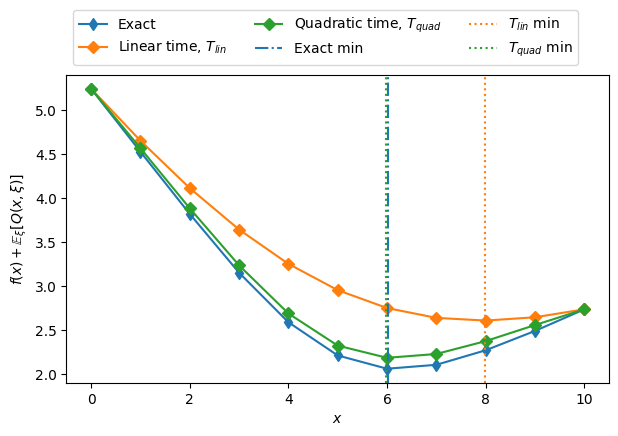

In [90]:
### this is really just for the ASCR proposal -- better figure c
plt.figure(figsize=(7,4))
plt.plot(bad_true_vec, '-d', label=r'Exact')
plt.plot(bad_qc_vec, '-D', color='tab:orange', label=r'Linear time, $T_{lin}$')
plt.plot(good_qc_vec, '-D', color='tab:green', label=r'Quadratic time, $T_{quad}$')
plt.axvline(np.argmin(bad_true_vec)+0.02, linestyle='-.', label='Exact min')
plt.axvline(np.argmin(bad_qc_vec)-.02, color='tab:orange', linestyle=':', label=r'$T_{lin}$ min')
plt.axvline(np.argmin(good_qc_vec)-.02, color='tab:green', linestyle=':', label=r'$T_{quad}$ min')

plt.ylabel(r'$f(x)+\mathbb{E}_\xi [Q(x,\xi)]$')
plt.xlabel(r'$x$')
plt.legend(bbox_to_anchor=(0., 1.01, 1., .102), ncols=3)

#plt.savefig("QSPworks.png", bbox_inches='tight')

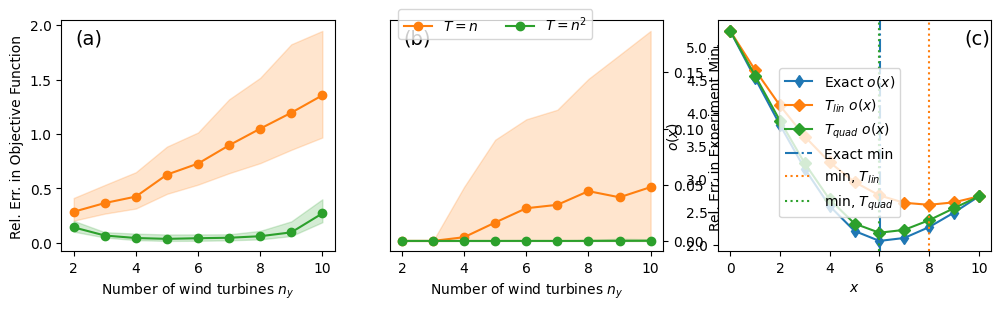

In [91]:
## Make Bigg Figg
#f, ax = plt.subplots(1, 3, figsize=(10,6))
#gs = gridspec.GridSpec(2, 4, figure=f)
#gs.update(wspace=0.5)
#ax[0] = plt.subplot(gs[0, :2], )
#ax[1] = plt.subplot(gs[0, 2:])
#ax[2] = plt.subplot(gs[1, 1:3])

f, ax = plt.subplots(1, 3, figsize=(12,3))
#gs = gridspec.GridSpec(2, 2, figure=f)
#ax[0] = plt.subplot(gs[0, 0], )
#ax[1] = plt.subplot(gs[0, 1])
#ax[2] = plt.subplot(gs[1, 0])
#gs = gridspec.GridSpec(2, 4, figure=f)
#gs.update(wspace=0.5)
#ax[0] = plt.subplot(gs[0, :2], )
#ax[1] = plt.subplot(gs[0, 2:])
#ax[2] = plt.subplot(gs[1, :2])


# fn comparison
subfig = ax[0]
subfig.fill_between(xd, 
                 np.array(fnrel_err_lin_mean)-np.array(fnrel_err_lin_lower), 
                 np.array(fnrel_err_lin_mean)+np.array(fnrel_err_lin_upper), 
                 alpha=.2, color='tab:orange')
subfig.plot(xd, fnrel_err_lin_mean, '-o', label=r'$T=n$', color='tab:orange')

subfig.fill_between(xd, 
                 np.array(fnrel_err_quad_mean)-np.array(fnrel_err_quad_lower), 
                 np.array(fnrel_err_quad_mean)+np.array(fnrel_err_quad_upper), 
                 alpha=.2, color='tab:green')
subfig.plot(xd, fnrel_err_quad_mean, '-o', label=r'$T=n^2$', color='tab:green')
subfig.set_ylabel(r'Rel. Err. in Objective Function', loc='center')
subfig.set_xlabel(r'Number of wind turbines $n_y$')
subfig.text(.05,.9, '(a)', transform=subfig.transAxes, fontsize=14)


# o* comparison
subfig = ax[1]
subfig.fill_between(xd, 
                 np.array(orel_err_lin_mean)-np.array(orel_err_lin_lower), 
                 np.array(orel_err_lin_mean)+np.array(orel_err_lin_upper), 
                 alpha=.2, color='tab:orange')
subfig.plot(xd, orel_err_lin_mean, '-o', color='tab:orange')

subfig.fill_between(xd, 
                 np.array(orel_err_quad_mean)-np.array(orel_err_quad_lower), 
                 np.array(orel_err_quad_mean)+np.array(orel_err_quad_upper), 
                 alpha=.2, color='tab:green')
subfig.plot(xd, orel_err_quad_mean, '-o', color='tab:green')
subfig.set_ylabel(r'Rel. Err. in Experiment Min.')
subfig.yaxis.tick_right()
subfig.yaxis.set_label_position('right')
subfig.set_xlabel(r'Number of wind turbines $n_y$')
subfig.text(.05,.9, '(b)', transform=subfig.transAxes, fontsize=14)

lines_labels = [a.get_legend_handles_labels() for a in f.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
f.legend(lines, labels, ncol=2, loc='upper left', bbox_to_anchor=(0.4, .94))


# compare one fn
subfig = ax[2]
subfig.plot(bad_true_vec, '-d', label=r'Exact $o(x)$')
subfig.plot(bad_qc_vec, '-D', color='tab:orange', label=r'$T_{lin}$ $o(x)$')
subfig.plot(good_qc_vec, '-D', color='tab:green', label=r'$T_{quad}$ $o(x)$')
subfig.axvline(np.argmin(bad_true_vec)+0.02, linestyle='-.', label='Exact min')
subfig.axvline(np.argmin(bad_qc_vec)-.02, color='tab:orange', linestyle=':', label=r'min, $T_{lin}$')
subfig.axvline(np.argmin(good_qc_vec)-.02, color='tab:green', linestyle=':', label=r'min, $T_{quad}$')
subfig.set_ylabel(r'$o(x)$')
subfig.set_xlabel(r'$x$')
subfig.text(.9,.9, '(c)', transform=subfig.transAxes, fontsize=14)


lines_labels = [a.get_legend_handles_labels() for a in f.axes]
lines, labels = subfig.get_legend_handles_labels()#[sum(lol, []) for lol in zip(*lines_labels)]
f.legend(lines, labels, ncol=1, loc='lower right', bbox_to_anchor=(.83, .2))

#plt.tight_layout()
#plt.show()
#gs.tight_layout(f)
#plt.savefig('qaoa_conv.pdf', bbox_inches='tight')

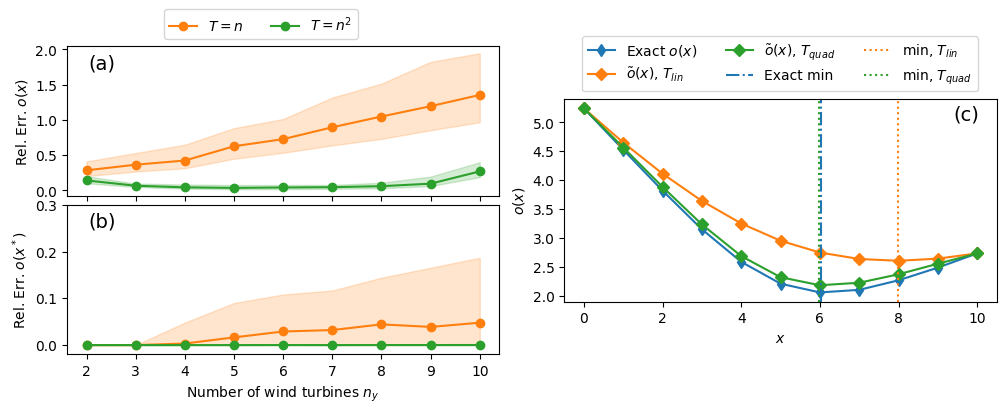

In [81]:
## Make Bigg Figg (different formating)
#f, ax = plt.subplots(1, 3, figsize=(12,3))
#fig = plt.figure(figsize=(12,3))

f = plt.figure(figsize=(12,4))

gs = fig.add_gridspec(6,2)
gs.update(wspace=0.15)
ax0 = f.add_subplot(gs[:3,0])
ax1 = f.add_subplot(gs[3:,0], sharex=ax0)
ax2 = f.add_subplot(gs[1:5,1])

# fn comparison
#subfig = fig.add_subplot(1,3,1, )
subfig = ax0
subfig.fill_between(xd, 
                 np.array(fnrel_err_lin_mean)-np.array(fnrel_err_lin_lower), 
                 np.array(fnrel_err_lin_mean)+np.array(fnrel_err_lin_upper), 
                 alpha=.2, color='tab:orange')
subfig.plot(xd, fnrel_err_lin_mean, '-o', label=r'$T=n$', color='tab:orange')

subfig.fill_between(xd, 
                 np.array(fnrel_err_quad_mean)-np.array(fnrel_err_quad_lower), 
                 np.array(fnrel_err_quad_mean)+np.array(fnrel_err_quad_upper), 
                 alpha=.2, color='tab:green')
subfig.plot(xd, fnrel_err_quad_mean, '-o', label=r'$T=n^2$', color='tab:green')
subfig.set_ylabel(r'Rel. Err. $o(x)$', loc='center')
subfig.set_xlabel(r'Number of wind turbines $n_y$')
subfig.text(.05,.85, '(a)', transform=subfig.transAxes, fontsize=14)


# o* comparison
#subfig = fig.add_subplot(1,3,2,)
subfig = ax1
subfig.fill_between(xd, 
                 np.array(orel_err_lin_mean)-np.array(orel_err_lin_lower), 
                 np.array(orel_err_lin_mean)+np.array(orel_err_lin_upper), 
                 alpha=.2, color='tab:orange')
subfig.plot(xd, orel_err_lin_mean, '-o', color='tab:orange')

subfig.fill_between(xd, 
                 np.array(orel_err_quad_mean)-np.array(orel_err_quad_lower), 
                 np.array(orel_err_quad_mean)+np.array(orel_err_quad_upper), 
                 alpha=.2, color='tab:green')
subfig.plot(xd, orel_err_quad_mean, '-o', color='tab:green')
subfig.set_ylabel(r'Rel. Err. $o(x^*)$')
#subfig.yaxis.tick_right()
#subfig.yaxis.set_label_position('right')
subfig.set_xlabel(r'Number of wind turbines $n_y$')
subfig.text(.05,.85, '(b)', transform=subfig.transAxes, fontsize=14)
subfig.set_ylim([-0.02,0.3])

lines_labels = [a.get_legend_handles_labels() for a in f.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
f.legend(lines, labels, ncol=2, loc='upper left', bbox_to_anchor=(0.2, .99))


# compare one fn
#subfig = fig.add_subplot(1,3,3, )
subfig = ax2
subfig.plot(bad_true_vec, '-d', label=r'Exact $o(x)$')
subfig.plot(bad_qc_vec, '-D', color='tab:orange', label=r'$\tilde o(x)$, $T_{lin}$')
subfig.plot(good_qc_vec, '-D', color='tab:green', label=r'$\tilde o(x)$, $T_{quad}$')
subfig.axvline(np.argmin(bad_true_vec)+0.02, linestyle='-.', label='Exact min')
subfig.axvline(np.argmin(bad_qc_vec)-.02, color='tab:orange', linestyle=':', label=r'min, $T_{lin}$')
subfig.axvline(np.argmin(good_qc_vec)-.02, color='tab:green', linestyle=':', label=r'min, $T_{quad}$')
subfig.set_ylabel(r'$o(x)$')
subfig.set_xlabel(r'$x$')
subfig.text(.9,.9, '(c)', transform=subfig.transAxes, fontsize=14)


lines_labels = [a.get_legend_handles_labels() for a in f.axes]
lines, labels = subfig.get_legend_handles_labels()#[sum(lol, []) for lol in zip(*lines_labels)]
f.legend(lines, labels, ncol=3, loc='lower right', bbox_to_anchor=(.89, .75))

#plt.tight_layout()
#plt.show()
#gs.tight_layout(f)
plt.savefig('qaoa_conv.pdf', bbox_inches='tight')

## Get samples for normal dist of PDF 

In [92]:
with open("binprob_data/run_record_normalpdf_linear.json", 'r') as json_file:
    run_record_normalpdf_linear = json.load(json_file)
    run_record_normalpdf_linear = {(int(s.split()[0][1:-1]), int(s.split()[1][:-1])):val for s,val in run_record_normalpdf_linear.items()}
    run_record_normalpdf_linear = {key0: 
                                   {key1: {int(x):o for x,o in value1.items()} 
                                    for key1,value1 in value0.items()} 
                                   for key0,value0 in run_record_normalpdf_linear.items()}
    
with open("binprob_data/run_record_normalpdf_square.json", 'r') as json_file:
    run_record_normalpdf_square = json.load(json_file)
    run_record_normalpdf_square = {(int(s.split()[0][1:-1]), int(s.split()[1][:-1])):val for s,val in run_record_normalpdf_square.items()}
    run_record_normalpdf_square = {key0: 
                                   {key1: {int(x):o for x,o in value1.items()} 
                                    for key1,value1 in value0.items()} 
                                   for key0,value0 in run_record_normalpdf_square.items()}


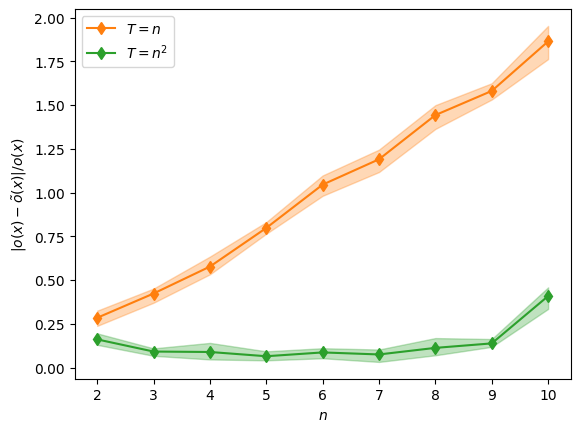

In [93]:
# combine linear and quadratic plot
nmin = 2
nmax = 11
samples = 20
xd = []
ydlinmeans = []
ydlinlower = []
ydlinupper = []
ydquadmeans = []
ydquadlower = []
ydquadupper = []
for n in range(nmin,nmax):
    xd.append(n)
    ydlin = []
    ydquad = []
    for sample in range(samples):
        
        # linear
        results = run_record_normalpdf_linear[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qc_energy_surface']
        true_vec = []
        qc_vec = []
        for x in range(n+1):
            true_vec.append(true[x])
            qc_vec.append(qc[x])
        true_vec = np.array(true_vec)
        #true_vec = true_vec[1:-1]
        #true_vec /= np.linalg.norm(true_vec)
        qc_vec = np.array(qc_vec)
        #qc_vec = qc_vec[1:-1]
        #qc_vec /= np.linalg.norm(qc_vec)
        #ydlin.append(true_vec.T @ qc_vec)
        ydlin.append(np.sum(np.abs(true_vec-qc_vec)/true_vec))
        #if ydlin[-1] > 1.8 or ydlin[-1] == 0:
        #    print('l', ydlin[-1], n, sample)
        
        # quadratic
        results = run_record_normalpdf_square[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qc_energy_surface']
        true_vec = []
        qc_vec = []
        for x in range(n+1):
            true_vec.append(true[x])
            qc_vec.append(qc[x])
        true_vec = np.array(true_vec)
        #true_vec = true_vec[1:-1]
        #true_vec /= np.linalg.norm(true_vec)
        qc_vec = np.array(qc_vec)
        #qc_vec = qc_vec[1:-1]
        #qc_vec /= np.linalg.norm(qc_vec)
        #ydquad.append(true_vec.T @ qc_vec)
        ydquad.append(np.sum(np.abs(true_vec-qc_vec)/true_vec))
        #if ydquad[-1] > 1.8 or ydquad[-1] < .20:
        #    print('q', ydquad[-1], n, sample)
        
    # process lin
    mlin = np.mean(ydlin)
    ydlinmeans.append(mlin)
    ydlinlower.append(mlin-np.min(ydlin))
    ydlinupper.append(np.max(ydlin)-mlin)
    # process quad
    mquad = np.mean(ydquad)
    ydquadmeans.append(mquad)
    ydquadlower.append(mquad-np.min(ydquad))
    ydquadupper.append(np.max(ydquad)-mquad)
    
fnrel_err_lin_mean = ydlinmeans
fnrel_err_lin_lower = ydlinlower
fnrel_err_lin_upper = ydlinupper
fnrel_err_quad_mean = ydquadmeans
fnrel_err_quad_lower = ydquadlower
fnrel_err_quad_upper = ydquadupper

plt.ylabel(r'$|o(x) - \tilde{o}(x)|/o(x)$')
plt.xlabel(r'$n$')
#plt.ylim([0.94, 1.001])
plt.fill_between(xd, np.array(ydlinmeans)-np.array(ydlinlower), np.array(ydlinmeans)+np.array(ydlinupper), alpha=.3, color='tab:orange')
plt.plot(xd,ydlinmeans, '-d', label=r'$T=n$', color='tab:orange')

plt.fill_between(xd, np.array(ydquadmeans)-np.array(ydquadlower), np.array(ydquadmeans)+np.array(ydquadupper), alpha=.3, color='tab:green')
plt.plot(xd,ydquadmeans, '-d', label=r'$T=n^2$', color='tab:green')

plt.legend(loc='upper left')

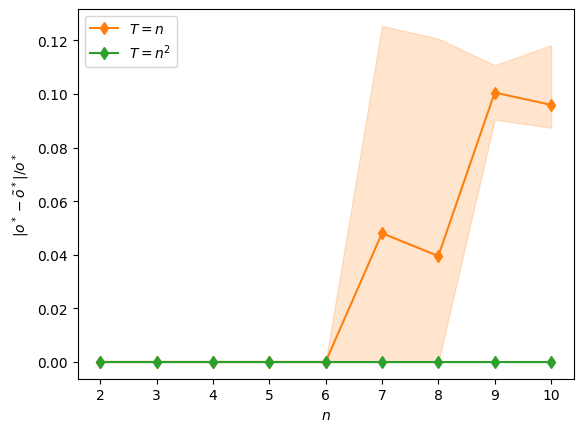

In [94]:
# get difference in answers
# combine linear and quadratic plot
nmin = 2
nmax = 11
samples = 20
xd = []
ydlinmeans = []
ydlinlower = []
ydlinupper = []
ydquadmeans = []
ydquadlower = []
ydquadupper = []
for n in range(nmin,nmax):
    xd.append(n)
    ydlin = []
    ydquad = []
    for sample in range(samples):
        
        # linear
        results = run_record_normalpdf_linear[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qc_energy_surface']
        true_vec = []
        qc_vec = []
        for x in range(n+1):
            true_vec.append(true[x])
            qc_vec.append(qc[x])
        true_vec = true_vec[1:-1]
        qc_vec = qc_vec[1:-1]
        x_min = np.argmin(true_vec)#, key=true.get)
        x_qc = np.argmin(qc_vec,)#, key=qc.get)
        o_qc = true_vec[x_qc]
        ydlin.append(np.abs(true_vec[x_min]-o_qc)/true_vec[x_min])
        
        # quadratic
        results = run_record_normalpdf_square[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qc_energy_surface']
        true_vec = []
        qc_vec = []
        for x in range(n+1):
            true_vec.append(true[x])
            qc_vec.append(qc[x])
        true_vec = true_vec[1:-1]
        qc_vec = qc_vec[1:-1]
        x_min = np.argmin(true_vec)#, key=true.get)
        x_qc = np.argmin(qc_vec,)#, key=qc.get)
        o_qc = true_vec[x_qc]
        ydquad.append(np.abs(true_vec[x_min]-o_qc)/true_vec[x_min])
    
    # process lin
    mlin = np.mean(ydlin)
    ydlinmeans.append(mlin)
    ydlinlower.append(mlin-np.min(ydlin))
    ydlinupper.append(np.max(ydlin)-mlin)
    
    # process quad
    mquad = np.mean(ydquad)
    ydquadmeans.append(mquad)
    ydquadlower.append(mquad-np.min(ydquad))
    ydquadupper.append(np.max(ydquad)-mquad)
    
orel_err_lin_mean = ydlinmeans
orel_err_lin_lower = ydlinlower
orel_err_lin_upper = ydlinupper
orel_err_quad_mean = ydquadmeans
orel_err_quad_lower = ydquadlower
orel_err_quad_upper = ydquadupper
    
#plt.ylim([0.9, 1.01])
plt.ylabel(r'$|o^*-\tilde{o}^*|/o^*$')
plt.xlabel(r'$n$')
#plt.errorbar(xd, ydlinmeans,  [ydlinlower, ydlinupper], label=r'$T=n$')
#plt.errorbar(xd, ydquadmeans, [ydquadlower, ydquadupper], label=r'$T=n^2$')
#plt.errorbar(xd, ydexpmeans, [ydexplower, ydexpupper], label=r'$T=\sqrt{2^n}$')
plt.fill_between(xd, np.array(ydlinmeans)-np.array(ydlinlower), np.array(ydlinmeans)+np.array(ydlinupper), alpha=.2, color='tab:orange')
plt.plot(xd,ydlinmeans, '-d', label=r'$T=n$', color='tab:orange')

plt.fill_between(xd, np.array(ydquadmeans)-np.array(ydquadlower), np.array(ydquadmeans)+np.array(ydquadupper), alpha=.2, color='tab:green')
plt.plot(xd,ydquadmeans, '-d', label=r'$T=n^2$', color='tab:green')

#plt.fill_between(xd, np.array(ydexpmeans)-np.array(ydexplower), np.array(ydexpmeans)+np.array(ydexpupper), alpha=.2)
#plt.plot(xd,ydexpmeans, '-d', label=r'$\sqrt{2^n}$')
plt.legend(loc='upper left')

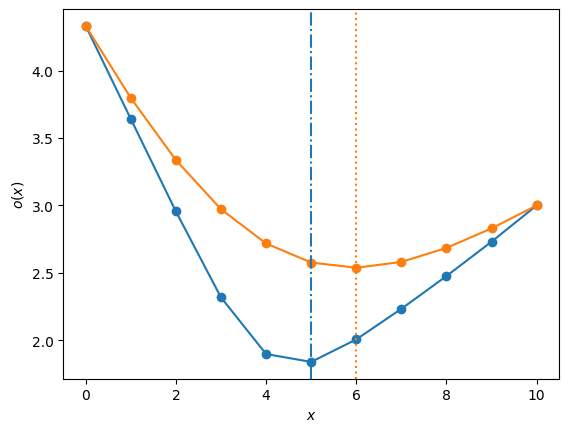

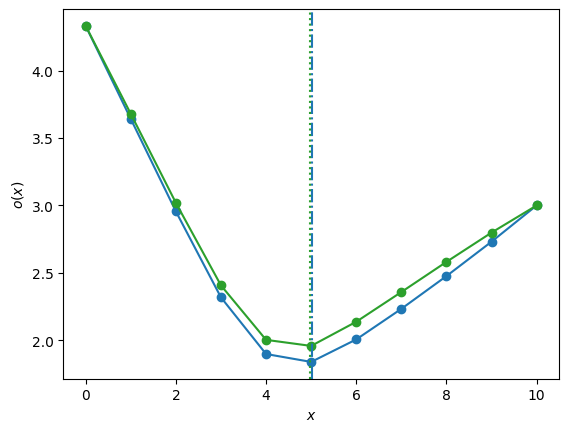

In [95]:
## Make plots of $o$
# n=10, sample=27  'bad'
# n=10, sample=29  'good'
si = 19

# bad line
n = 10
sample = si
results = run_record_normalpdf_linear[(n,sample)]
true = results['true_energy_surface']
qc = results['qc_energy_surface']
true_vec = []
qc_vec = []
for x in range(n+1):
    true_vec.append(true[x])
    qc_vec.append(qc[x])
bad_true_vec = true_vec
bad_qc_vec = qc_vec
plt.ylabel(r'$o(x)$')
plt.xlabel(r'$x$')
plt.plot(true_vec, '-o')
plt.plot(qc_vec, '-o')
plt.axvline(np.argmin(true_vec), linestyle='-.')
plt.axvline(np.argmin(qc_vec), color='tab:orange', linestyle=':')
plt.show()

# good line
n = 10
sample = si
results = run_record_normalpdf_square[(n,sample)]
true = results['true_energy_surface']
qc = results['qc_energy_surface']
true_vec = []
qc_vec = []
for x in range(n+1):
    true_vec.append(true[x])
    qc_vec.append(qc[x])
good_true_vec = true_vec
good_qc_vec = qc_vec 
plt.ylabel(r'$o(x)$')
plt.xlabel(r'$x$')
plt.plot(true_vec, '-o')
plt.plot(qc_vec, '-o', color='tab:green')
plt.axvline(np.argmin(true_vec)+0.02, linestyle='-.')
plt.axvline(np.argmin(qc_vec)-.02, color='tab:green', linestyle=':')

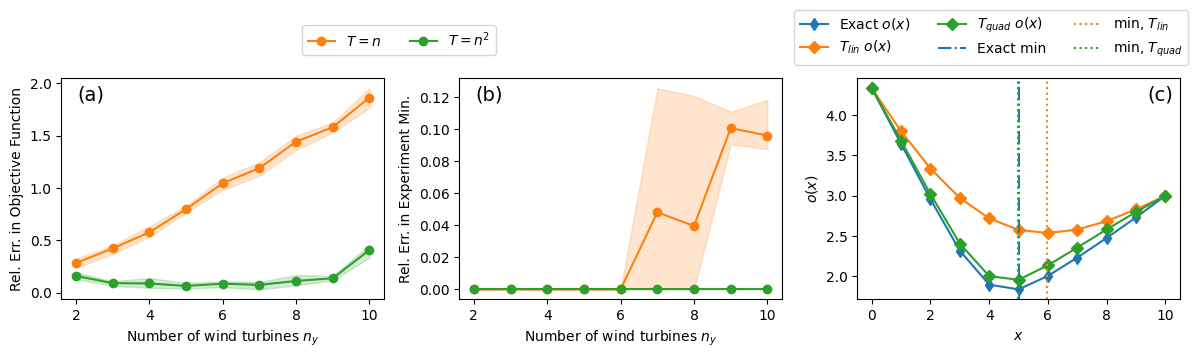

In [96]:
## Make Bigg Figg
f, ax = plt.subplots(1, 3, figsize=(12,3))

# fn comparison
subfig = ax[0]
subfig.fill_between(xd, 
                 np.array(fnrel_err_lin_mean)-np.array(fnrel_err_lin_lower), 
                 np.array(fnrel_err_lin_mean)+np.array(fnrel_err_lin_upper), 
                 alpha=.2, color='tab:orange')
subfig.plot(xd, fnrel_err_lin_mean, '-o', label=r'$T=n$', color='tab:orange')

subfig.fill_between(xd, 
                 np.array(fnrel_err_quad_mean)-np.array(fnrel_err_quad_lower), 
                 np.array(fnrel_err_quad_mean)+np.array(fnrel_err_quad_upper), 
                 alpha=.2, color='tab:green')
subfig.plot(xd, fnrel_err_quad_mean, '-o', label=r'$T=n^2$', color='tab:green')
subfig.set_ylabel(r'Rel. Err. in Objective Function')
subfig.set_xlabel(r'Number of wind turbines $n_y$')
subfig.text(.05,.9, '(a)', transform=subfig.transAxes, fontsize=14)


# o* comparison
subfig = ax[1]
subfig.fill_between(xd, 
                 np.array(orel_err_lin_mean)-np.array(orel_err_lin_lower), 
                 np.array(orel_err_lin_mean)+np.array(orel_err_lin_upper), 
                 alpha=.2, color='tab:orange')
subfig.plot(xd, orel_err_lin_mean, '-o', color='tab:orange')

subfig.fill_between(xd, 
                 np.array(orel_err_quad_mean)-np.array(orel_err_quad_lower), 
                 np.array(orel_err_quad_mean)+np.array(orel_err_quad_upper), 
                 alpha=.2, color='tab:green')
subfig.plot(xd, orel_err_quad_mean, '-o', color='tab:green')
subfig.set_ylabel(r'Rel. Err. in Experiment Min.')
subfig.set_xlabel(r'Number of wind turbines $n_y$')
subfig.text(.05,.9, '(b)', transform=subfig.transAxes, fontsize=14)

lines_labels = [a.get_legend_handles_labels() for a in f.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
f.legend(lines, labels, ncol=2, loc='upper left', bbox_to_anchor=(0.25, 1.15))


# compare one fn
subfig = ax[2]
subfig.plot(bad_true_vec, '-d', label=r'Exact $o(x)$')
subfig.plot(bad_qc_vec, '-D', color='tab:orange', label=r'$T_{lin}$ $o(x)$')
subfig.plot(good_qc_vec, '-D', color='tab:green', label=r'$T_{quad}$ $o(x)$')
subfig.axvline(np.argmin(bad_true_vec)+0.02, linestyle='-.', label='Exact min')
subfig.axvline(np.argmin(bad_qc_vec)-.02, color='tab:orange', linestyle=':', label=r'min, $T_{lin}$')
subfig.axvline(np.argmin(good_qc_vec)-.02, color='tab:green', linestyle=':', label=r'min, $T_{quad}$')
subfig.set_ylabel(r'$o(x)$')
subfig.set_xlabel(r'$x$')
subfig.text(.9,.9, '(c)', transform=subfig.transAxes, fontsize=14)


lines_labels = [a.get_legend_handles_labels() for a in f.axes]
lines, labels = subfig.get_legend_handles_labels()#[sum(lol, []) for lol in zip(*lines_labels)]
f.legend(lines, labels, ncol=3, loc='upper right', bbox_to_anchor=(1, 1.2))

plt.tight_layout()
plt.show()

# Compare QAE to Shots, n=[3,4], pdf=uniform,skewednormal

In [97]:
uni = True
n = 3
mf = 10
nmeas = 1
m_fname = 'measurement_data/measure_uniform={}_n={}_m={}_nmeas={}.pkl'.format(uni,n,mf,nmeas)
with open(m_fname, 'rb') as f:
    results = pickle.load(f)

alpha = .7
m = 7
density = False
log = True
bin1 = 50
bin2 = None
ci = 8/np.pi**2 * 100
c = results['classical_sampling_estimates'][m+1]
q = results['qae_estimates'][m]
ev_exact = results['ground_state_expectation_value']

# show the PMF
fig = plt.figure()

plt.axvline(ev_exact, color='red', label=r'$\phi(x)$', linestyle='--')
plt.hist(c, bins=bin1, density=density, log=log, label='Shots', color='cornflowerblue')
plt.hist(q, alpha=alpha, density=density, bins=bin2, log=log, label='QAE', color='limegreen')

plt.axvline(np.percentile(c, ci), color='darkblue', linestyle='-.', label='Shots 81% CI')
plt.axvline(np.percentile(c, 100-ci), color='darkblue', linestyle='-.')
plt.axvline(np.percentile(q, ci), color='darkgreen', linestyle=':', label='QAE 81% CI')
plt.axvline(np.percentile(q, 100-ci), color='darkgreen', linestyle=':')
#locs, _ = plt.yticks() 
#plt.yticks(locs,np.round(locs/len(c),3))
#plt.xlim([.5,1.])
plt.ylabel(r'log(Frequency)')
plt.xlabel(r'$\tilde{\phi}(x)$')
plt.legend()
plt.show()


'''
# show the CMF
resolution = 1_000
fig = plt.figure()

ccounts,cbins, _ = plt.hist(c, bins=bin1, density=False, cumulative=True)
qcounts, qbins, _ = plt.hist(q, density=False, bins=bin2, cumulative=True)
plt.cla()
plt.axvline(ev_exact, color='red', label=r'$\phi(x)$', linestyle='--')
plt.plot(cbins[:-1], ccounts)
plt.plot(qbins[:-1], qcounts)

locs, _ = plt.yticks() 
plt.yticks(locs,np.round(locs/len(c),3))
plt.ylabel(r'CMF of estimate')
plt.xlabel(r'$\tilde{\mathbb{E}}$')

plt.show()
'''


ImportError: cannot import name 'Aer' from 'qiskit' (/Users/crotello/.local/lib/python3.11/site-packages/qiskit/__init__.py)

In [98]:
uni = True
n = 3
mf = 10
nmeas = 1
m_fname = 'measurement_data/measure_uniform={}_n={}_m={}_nmeas={}.pkl'.format(uni,n,mf,nmeas)
with open(m_fname, 'rb') as f:
    results = pickle.load(f)

alpha = .9
density = False
log = True
bin1 = 50
bin2 = 50
ci = 8/np.pi**2 * 100

f, ax = plt.subplots(3, 3, sharey=True)
for m in range(1,mf):
    c = results['classical_sampling_estimates'][m+1]
    q = results['qae_estimates'][m]
    ev_exact = results['ground_state_expectation_value']

    # show the PMF
    subfig = ax[int((m-1)/3), m%3-1]
    subfig.axvline(ev_exact, color='red', label=r'$\phi(x)$', linestyle='--')
    subfig.hist(c, bins=bin1, density=density, log=log, label='Shots', color='cornflowerblue')
    subfig.hist(q, alpha=alpha, density=density, bins=bin2, log=log, label='QAE', color='limegreen')

    subfig.axvline(np.percentile(c, ci), color='darkblue', linestyle='-.', label='Shots 81% CI')
    subfig.axvline(np.percentile(c, 100-ci), color='darkblue', linestyle='-.')
    subfig.axvline(np.percentile(q, ci), color='darkgreen', linestyle=':', label='QAE 81% CI')
    subfig.axvline(np.percentile(q, 100-ci), color='darkgreen', linestyle=':')
    subfig.text(.7,.8,'m={}'.format(m), transform=subfig.transAxes)
    subfig.set_xlim([.5,1])
plt.xlabel(r'$\phi(x)$')
plt.ylabel(r'Probability')
plt.show()

# CMF
bin1 = 100
bin2 = 100
f, ax = plt.subplots(3, 3, sharey=True)
for m in range(1,mf):
    c = results['classical_sampling_estimates'][m+1]
    q = results['qae_estimates'][m]
    ev_exact = results['ground_state_expectation_value']

    subfig = ax[int((m-1)/3), m%3-1]    
    subfig.axvline(ev_exact, color='red', label=r'$\phi(x)$', linestyle='--')
    ccounts,cbins, _ = subfig.hist(c, bins=bin1, density=False, cumulative=True)
    qcounts, qbins, _ = subfig.hist(q, density=False, bins=bin2, cumulative=True)
    subfig.cla()
    subfig.axvline(ev_exact, color='red', label=r'$\phi(x)$', linestyle='--')
    subfig.plot(cbins[:-1], ccounts)
    subfig.plot(qbins[:-1], qcounts)
    subfig.set_xlim([0.5,1.])
    
    subfig.text(.05,.8,'m={}'.format(m), transform=subfig.transAxes)


ImportError: cannot import name 'Aer' from 'qiskit' (/Users/crotello/.local/lib/python3.11/site-packages/qiskit/__init__.py)

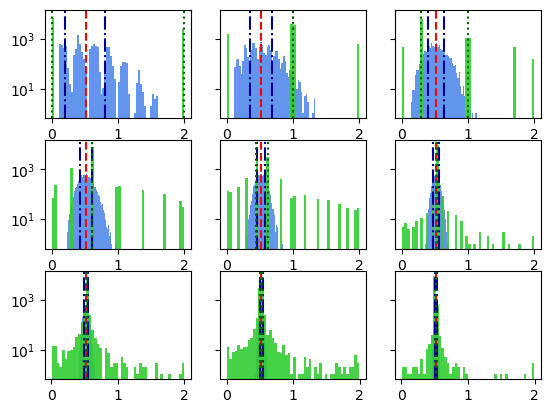

In [10]:
uni = False
n = 3
mf = 9
nmeas = 1
m_fname = 'measurement_data/measure_uniform={}_n={}_m={}_nmeas={}.pkl'.format(uni,n,mf,nmeas)
with open(m_fname, 'rb') as f:
    results = pickle.load(f)

alpha = .9
density = False
log = True
bin1 = 50
bin2 = 50
ci = 8/np.pi**2 * 100

f, ax = plt.subplots(3, 3, sharey=True)
for m in range(1,mf+1):
    c = results['classical_sampling_estimates'][m+1]
    q = results['qae_estimates'][m]
    ev_exact = results['ground_state_expectation_value']

    # show the PMF
    #fig = plt.figure()
    subfig = ax[int((m-1)/3), m%3-1]
    subfig.axvline(ev_exact, color='red', label=r'$\phi(x)$', linestyle='--')
    subfig.hist(c, bins=bin1, density=density, log=log, label='Shots', color='cornflowerblue')
    subfig.hist(q, alpha=alpha, density=density, bins=bin2, log=log, label='QAE', color='limegreen')

    subfig.axvline(np.percentile(c, ci), color='darkblue', linestyle='-.', label='Shots 81% CI')
    subfig.axvline(np.percentile(c, 100-ci), color='darkblue', linestyle='-.')
    subfig.axvline(np.percentile(q, ci), color='darkgreen', linestyle=':', label='QAE 81% CI')
    subfig.axvline(np.percentile(q, 100-ci), color='darkgreen', linestyle=':')
    #subfig.ylabel(r'log(Frequency)')
    #subfig.xlabel(r'$\tilde{\mathbb{E}}$')
    #plt.legend()
    #plt.show()

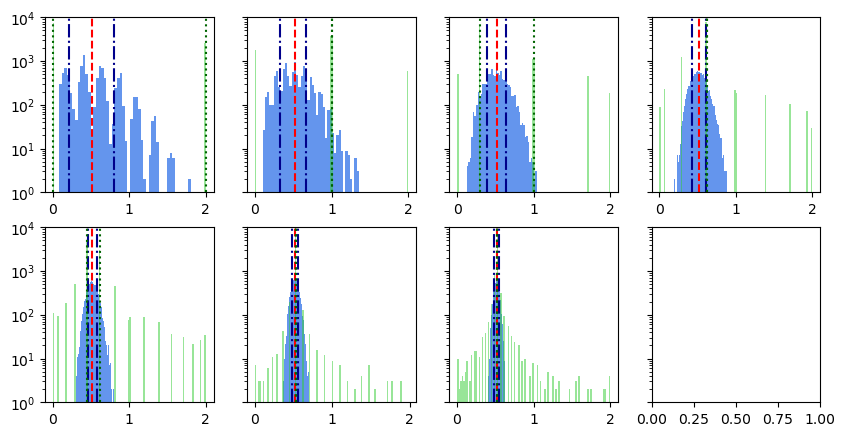

In [22]:
uni = True
n = 4
mf = 7
nmeas = 1
m_fname = 'measurement_data/measure_uniform={}_n={}_m={}_nmeas={}.pkl'.format(uni,n,mf,nmeas)
with open(m_fname, 'rb') as f:
    results = pickle.load(f)

alpha = .5
density = False
log = True
bin1 = 50
bin2 = 100
ci = 8/np.pi**2 * 100

f, ax = plt.subplots(2, 4, sharey=True, figsize=(10,5))
for m in range(1,mf+1):
    c = results['classical_sampling_estimates'][m+1]
    q = results['qae_estimates'][m]
    ev_exact = results['ground_state_expectation_value']

    # show the PMF
    #fig = plt.figure()
    subfig = ax[int((m-1)/4), m%4-1]
    subfig.axvline(ev_exact, color='red', label=r'$\phi(x)$', linestyle='--')
    subfig.hist(c, bins=bin1, density=density, log=log, label='Shots', color='cornflowerblue')
    subfig.hist(q, alpha=alpha, density=density, bins=bin2, log=log, label='QAE', color='limegreen')

    if True:
        subfig.axvline(np.percentile(c, ci), color='darkblue', linestyle='-.', label='Shots 81% CI')
        subfig.axvline(np.percentile(c, 100-ci), color='darkblue', linestyle='-.')
        subfig.axvline(np.percentile(q, ci), color='darkgreen', linestyle=':', label='QAE 81% CI')
        subfig.axvline(np.percentile(q, 100-ci), color='darkgreen', linestyle=':')
    
    subfig.set_ylim([1,10**4])
    #subfig.set_xlim([0,1])




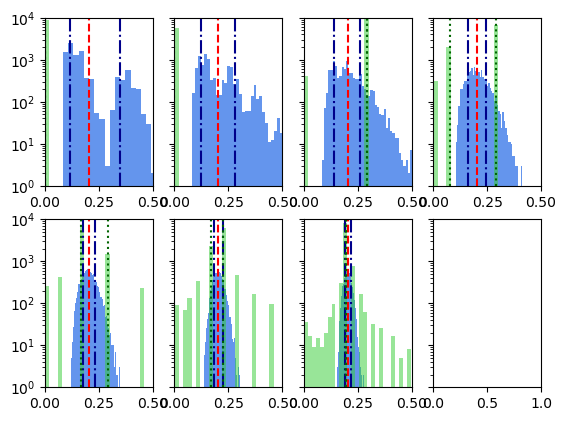

In [23]:
uni = False
n = 4
mf = 7
nmeas = 1
m_fname = 'measurement_data/measure_uniform={}_n={}_m={}_nmeas={}.pkl'.format(uni,n,mf,nmeas)
with open(m_fname, 'rb') as f:
    results = pickle.load(f)

alpha = .5
density = False
log = True
bin1 = 50
bin2 = 100
ci = 8/np.pi**2 * 100

f, ax = plt.subplots(2, 4, sharey=True)
for m in range(1,mf+1):
    c = results['classical_sampling_estimates'][m+1]
    q = results['qae_estimates'][m]
    ev_exact = results['ground_state_expectation_value']

    # show the PMF
    #fig = plt.figure()
    subfig = ax[int((m-1)/4), m%4-1]
    subfig.axvline(ev_exact, color='red', label=r'$\phi(x)$', linestyle='--')
    subfig.hist(c, bins=bin1, density=density, log=log, label='Shots', color='cornflowerblue')
    subfig.hist(q, alpha=alpha, density=density, bins=bin2, log=log, label='QAE', color='limegreen')

    subfig.axvline(np.percentile(c, ci), color='darkblue', linestyle='-.', label='Shots 81% CI')
    subfig.axvline(np.percentile(c, 100-ci), color='darkblue', linestyle='-.')
    subfig.axvline(np.percentile(q, ci), color='darkgreen', linestyle=':', label='QAE 81% CI')
    subfig.axvline(np.percentile(q, 100-ci), color='darkgreen', linestyle=':')
    
    subfig.set_ylim([1,10**4])
    subfig.set_xlim([0,.5])
    #subfig.ylabel(r'log(Frequency)')
    #subfig.xlabel(r'$\tilde{\mathbb{E}}$')
    #plt.legend()
    #plt.show()



## Pick the n=3,4 datasets from above and use the easiest to read plots

dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
bin width: 0.022368421052631593


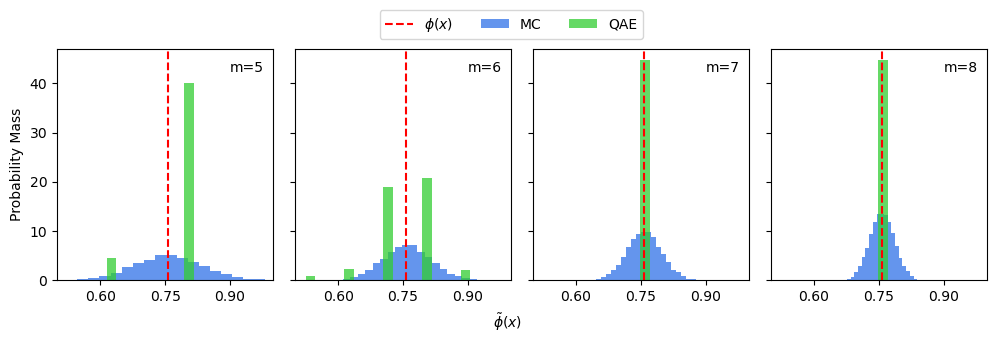

In [423]:
uni = True
n = 3
mf = 10
nmeas = 1
m_fname = 'measurement_data/measure_uniform={}_n={}_m={}_nmeas={}.pkl'.format(uni,n,mf,nmeas)
with open(m_fname, 'rb') as f:
    results = pickle.load(f)
print(results['qae_estimates'].keys())
alpha = .75
density = True#False
log = False#True
bin1 = 25


#bin2 = [50,50,20,15]#[50,50,[0.6,0.7,0.73,0.77]]
b = np.linspace(.525,.95,20)
print('bin width:', b[1]-b[0])
bin2=[b,b,b,b]
ci = 8/np.pi**2 * 100

f, ax = plt.subplots(1,4, sharey=True, figsize=(12,3))
#ax = [ax[0,0], ax[0,1], ax[1,0], ax[1,1]]
mfs = [5,6,7,8]
for i,m in enumerate(mfs):#range(1,mf):
    c = np.array(results['classical_sampling_estimates'][m+1])
    q = np.array(results['qae_estimates'][m])
    ev_exact = results['ground_state_expectation_value']

    # show the PMF
    subfig = ax[i]
    subfig.axvline(ev_exact, color='red', label=r'$\phi(x)$', linestyle='--')
    subfig.hist(c, bins=bin1, density=density, log=log, label='MC', color='cornflowerblue', rasterized=True, antialiased=True, linewidth=0.0, stacked=True)
    subfig.hist(q, alpha=alpha, density=density, bins=bin2[i], log=log, label='QAE', color='limegreen', rasterized=True, stacked=True)

    #subfig.axvline(np.percentile(c, ci), color='darkblue', linestyle='-.', label='Shots 81% CI')
    #subfig.axvline(np.percentile(c, 100-ci), color='darkblue', linestyle='-.')
    #subfig.axvline(np.percentile(q, ci), color='darkgreen', linestyle=':', label='QAE 81% CI')
    #subfig.axvline(np.percentile(q, 100-ci), color='darkgreen', linestyle=':')
    subfig.text(.8,.9,'m={}'.format(m), transform=subfig.transAxes)
    subfig.set_xlim([0.5,1.])
    
    if i == 1:
    #    #subfig.set_xlabel(r'$\tilde{\phi}(x)$')
        subfig.legend(loc='upper center', ncol=3, bbox_to_anchor=(1., 1.2))
    if i == 0:
        subfig.set_ylabel(r'Probability Mass')
    subfig.set_xticks([0.6, 0.75, 0.9])
    #subfig.set_yticks([])
        
## plot nonsense
f.text(.5, -.03, r'$\tilde{\phi}(x)$', ha='center', va='center')
plt.subplots_adjust(wspace=.1, hspace=0)
#f.legend(loc='upper center', ncol=3, bbox_to_anchor=(1.2, 1.3))
plt.savefig('qae_conv.pdf', bbox_inches='tight', dpi=500)

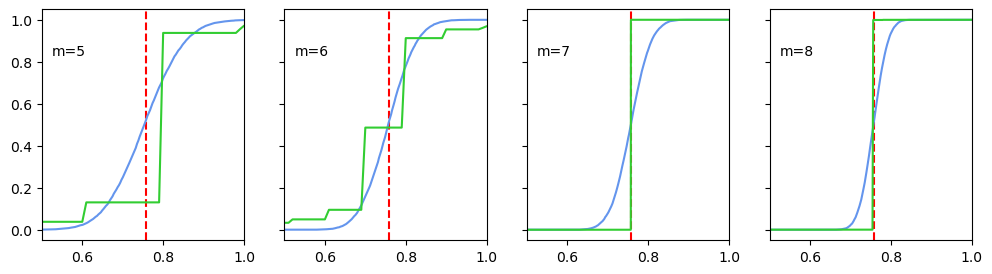

In [391]:
## CDF - seperate cell for clarity
f, ax = plt.subplots(1,4, sharey=True, figsize=(12,3))
#ax = [ax[0,0], ax[0,1], ax[1,0], ax[1,1]]
size = 10_000
mfs = [5,6,7,8]
bin1 = 200
bin2 = 200
for i,m in enumerate(mfs):
    c = results['classical_sampling_estimates'][m+1]
    q = results['qae_estimates'][m]
    ev_exact = results['ground_state_expectation_value']

    subfig = ax[i]#int((m-1)/3), m%3-1]    
    subfig.axvline(ev_exact, color='red', label=r'$\phi(x)$', linestyle='--')
    ccounts,cbins, _ = subfig.hist(c, bins=bin1, density=False, cumulative=True)
    qcounts,qbins, _ = subfig.hist(q, density=False, bins=bin2, cumulative=True)
    subfig.cla()
    ccounts /= size
    qcounts /= size
    subfig.axvline(ev_exact, color='red', label=r'$\phi(x)$', linestyle='--')
    subfig.plot([0]+list(cbins[:-1])+[2], [0]+list(ccounts)+[1], color='cornflowerblue')
    subfig.plot([0]+list(qbins[:-1])+[2], [0]+list(qcounts)+[1], color='limegreen')
    subfig.set_xlim([0.5,1.])
    subfig.set_ylim([-.05, 1.05])
    
    subfig.text(.05,.8,'m={}'.format(m), transform=subfig.transAxes)
    

dict_keys([1, 2, 3, 4, 5, 6, 7])


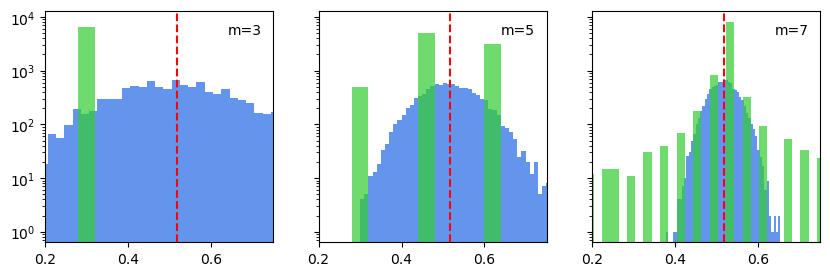

In [238]:
uni = True
n = 4
mf = 7
nmeas = 1
m_fname = 'measurement_data/measure_uniform={}_n={}_m={}_nmeas={}.pkl'.format(uni,n,mf,nmeas)
with open(m_fname, 'rb') as f:
    results = pickle.load(f)
print(results['qae_estimates'].keys())

alpha = .7
density = False
log = True
bin1 = 50
bin2 = [50,50,100]
ci = 8/np.pi**2 * 100

f, ax = plt.subplots(1, 3, sharey=True, figsize=(10,3))
mfs = [3,5,7]
for i,m in enumerate(mfs):#range(1,mf):
    c = results['classical_sampling_estimates'][m+1]
    q = results['qae_estimates'][m]
    ev_exact = results['ground_state_expectation_value']

    # show the PMF
    subfig = ax[i]
    subfig.axvline(ev_exact, color='red', label=r'$\phi(x)$', linestyle='--')
    subfig.hist(c, bins=bin1, density=density, log=log, label='Shots', color='cornflowerblue')
    subfig.hist(q, alpha=alpha, density=density, bins=bin2[i], log=log, label='QAE', color='limegreen')

    #subfig.axvline(np.percentile(c, ci), color='darkblue', linestyle='-.', label='Shots 81% CI')
    #subfig.axvline(np.percentile(c, 100-ci), color='darkblue', linestyle='-.')
    #subfig.axvline(np.percentile(q, ci), color='darkgreen', linestyle=':', label='QAE 81% CI')
    #subfig.axvline(np.percentile(q, 100-ci), color='darkgreen', linestyle=':')
    subfig.text(.8,.9,'m={}'.format(m), transform=subfig.transAxes)
    subfig.set_xlim([0.2,0.75])

    

# Test with optimization in the loop
Track good experiments here (some had been run with bugs). Tuple is (n,m,T)
(4,4,10), (4,6,10), (4,8,10)
(5,6,15)
(6,5,20)

[2.4000000000000004, 2.0593125, 1.8613125000000004, 1.9006875, 2.2161875, 2.7275000000000005, 3.3150000000000004]


Text(0, 0.5, '$o(x)$')

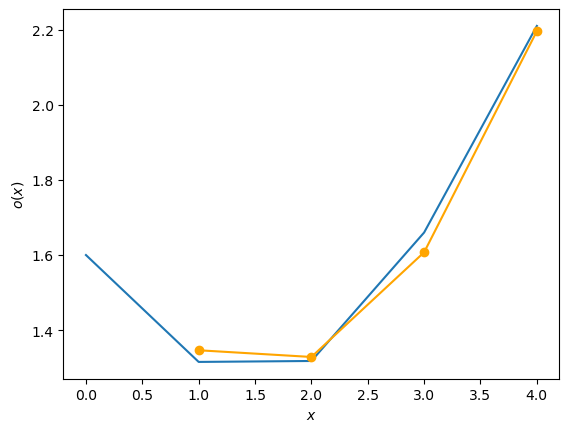

In [320]:
fname_fn = lambda T,o,uni,n,m : 'sampling_data/sampling_T={}_exactoracle={}_uniform={}_n={}_m={}.pkl'.format(T,o,uni,n,m)
#fname_fn = lambda uni,n,m : 'sampling_data/sampling_uniform={}_n={}_m={}.pkl'.format(uni,n,m)

n = 4
m = 6
uni = True
T = 10
exactoracle = False

fname = fname_fn(T,exactoracle,uni,n,m)
#fname = fname_fn(uni,n,m)

nmeas_qae = 1
nmeas = 10_0000


with open(fname, 'rb') as f:
    results = pickle.load(f)

    
#print(results.keys())
bno = results['model']
e = bno.brute_force_wind_demand_expectation_values()
#print(e)
    
trues_4_6_10 =[bno.gas_costs[0] * (n-d) + e[d] for d in range(n+1)]
print(trues)
oracle_estimates = []
estimates_4_6_10 = []
wvfns = []
demands = list(range(1,n+1))
for d in demands:
    #print(results['data'][d].keys())
    norm = (d)*bno.recourse_cost
    
    qae_wvfn = results['data'][d]['qae_state']
    counts = qae_wvfn.sample_counts(nmeas_qae, qargs=list(range(m)))
    estimate = np.sum([np.sin(int(b,2)*np.pi/2**m)**2 * norm * val/nmeas_qae for b,val in counts.items()])
    estimates_4_6_10.append(bno.gas_costs[0]*(n-d) + estimate)
    
    oracle_wvfn = results['data'][d]['oracle_state']
    #print(oracle_wvfn.probabilities_dict())
    counts = oracle_wvfn.probabilities_dict(qargs=[2*n])#sample_counts(nmeas, qargs=[2*n])
    #print(counts)
    estimate = np.sum([int(b)*norm * val for b,val in counts.items()])
    oracle_estimates.append(bno.gas_costs[0]*(n-d) + estimate)
    
    wvfn = results['data'][d]['qaoa_state']
    measurements = wvfn.sample_counts(nmeas)
    measurements = {val: count/nmeas for val,count in measurements.items()}
    est_exp_val = bno.process_expectation_value_optimizer(d, measurements)
    wvfns.append(bno.gas_costs[0]*(n-d) + est_exp_val)
    
plt.plot([0]+demands, trues_4_6_10)
plt.plot(demands, estimates_4_6_10, '-o', color='orange')
plt.xlabel(r'$x$')
plt.ylabel(r'$o(x)$')

#plt.plot(demands, oracle_estimates, '-o', color='purple')
#plt.plot(demands, wvfns, '-o', color='red')

[2.4000000000000004, 2.0593125, 1.8613125000000004, 1.9006875, 2.2161875, 2.7275000000000005, 3.3150000000000004]


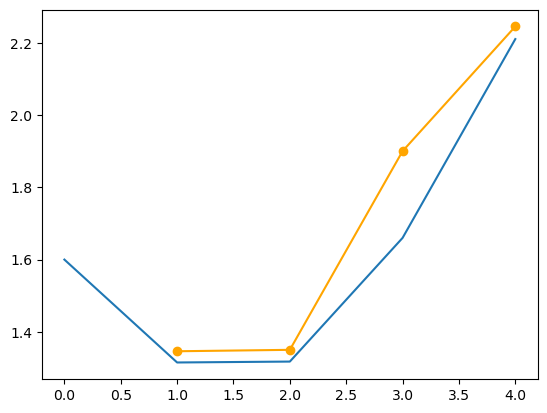

In [321]:
n = 4
m = 8
uni = True
T = 10
exactoracle = False

fname = fname_fn(T,exactoracle,uni,n,m)
with open(fname, 'rb') as f:
    results = pickle.load(f)

nmeas_qae = 1

bno = results['model']
e = bno.brute_force_wind_demand_expectation_values()

trues_4_8_10 =[bno.gas_costs[0] * (n-d) + e[d] for d in range(n+1)]
print(trues)

estimates_4_8_10 = []
demands = list(range(1,n+1))
for d in demands:
    #print(results['data'][d].keys())
    norm = (d)*bno.recourse_cost
    
    qae_wvfn = results['data'][d]['qae_state']
    counts = qae_wvfn.sample_counts(nmeas_qae, qargs=list(range(m)))
    estimate = np.sum([np.sin(int(b,2)*np.pi/2**m)**2 * norm * val/nmeas_qae for b,val in counts.items()])
    estimates_4_8_10.append(bno.gas_costs[0]*(n-d) + estimate)
    
plt.plot([0]+demands, trues_4_8_10)
plt.plot(demands, estimates_4_8_10, '-o', color='orange')

[2.4000000000000004, 2.0593125, 1.8613125000000004, 1.9006875, 2.2161875, 2.7275000000000005, 3.3150000000000004]


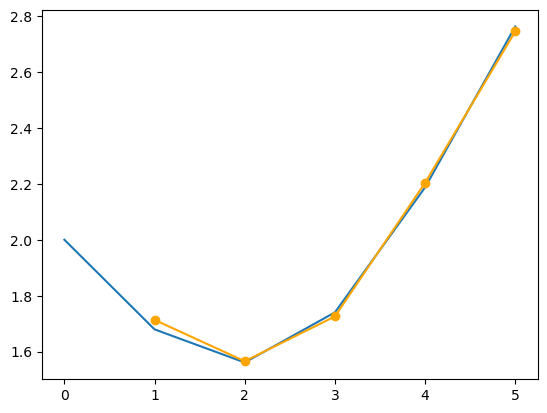

In [322]:
n = 5
m = 6
uni = True
T = 15
exactoracle = False

fname = fname_fn(T,exactoracle,uni,n,m)
with open(fname, 'rb') as f:
    results = pickle.load(f)

nmeas_qae = 1

bno = results['model']
e = bno.brute_force_wind_demand_expectation_values()

trues_5_6_15 =[bno.gas_costs[0] * (n-d) + e[d] for d in range(n+1)]
print(trues)

estimates_5_6_15 = []
demands = list(range(1,n+1))
for d in demands:
    #print(results['data'][d].keys())
    norm = (d)*bno.recourse_cost
    
    qae_wvfn = results['data'][d]['qae_state']
    counts = qae_wvfn.sample_counts(nmeas_qae, qargs=list(range(m)))
    estimate = np.sum([np.sin(int(b,2)*np.pi/2**m)**2 * norm * val/nmeas_qae for b,val in counts.items()])
    estimates_5_6_15.append(bno.gas_costs[0]*(n-d) + estimate)
    
plt.plot([0]+demands, trues_5_6_15)
plt.plot(demands, estimates_5_6_15, '-o', color='orange')

[2.4000000000000004, 2.0593125, 1.8613125000000004, 1.9006875, 2.2161875, 2.7275000000000005, 3.3150000000000004]


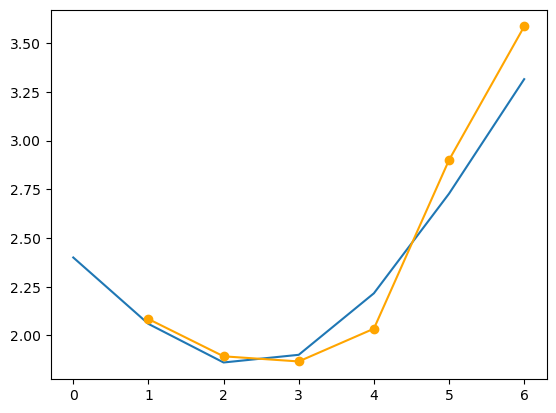

In [325]:
n = 6
m = 5
uni = True
T = 20
exactoracle = False

fname = fname_fn(T,exactoracle,uni,n,m)
with open(fname, 'rb') as f:
    results = pickle.load(f)

nmeas_qae = 1

bno = results['model']
e = bno.brute_force_wind_demand_expectation_values()

trues_6_5_20 =[bno.gas_costs[0] * (n-d) + e[d] for d in range(n+1)]
print(trues)

estimates_6_5_20 = []
demands = list(range(1,n+1))
for d in demands:
    #print(results['data'][d].keys())
    norm = (d)*bno.recourse_cost
    
    qae_wvfn = results['data'][d]['qae_state']
    counts = qae_wvfn.sample_counts(nmeas_qae, qargs=list(range(m)))
    estimate = np.sum([np.sin(int(b,2)*np.pi/2**m)**2 * norm * val/nmeas_qae for b,val in counts.items()])
    estimates_6_5_20.append(bno.gas_costs[0]*(n-d) + estimate)
    
plt.plot([0]+demands, trues_6_5_20)
plt.plot(demands, estimates_6_5_20, '-o', color='orange')

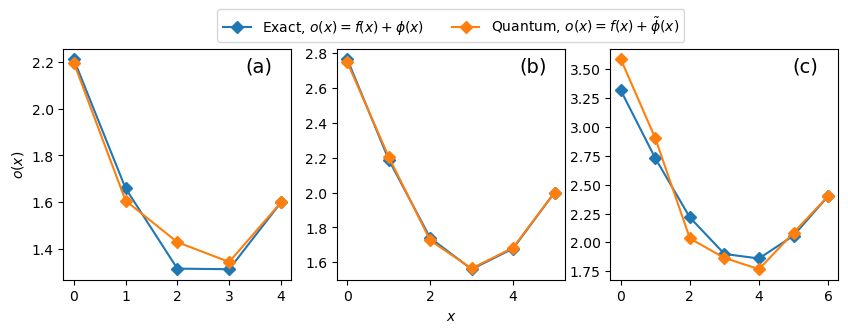

In [294]:
## ALL TOGETHER FOR IGG FIGGA
f, ax = plt.subplots(1, 3, figsize=(10,3),)# sharey=True,)


# haha idiot, forgot to reverse to order on the x axis; just do it here so we can make figures
subfig = ax[0]
demands = list(range(0,5))
subfig.plot(demands, trues_4_6_10[::-1], '-D')
subfig.plot(demands, list(estimates_4_6_10[::-1]) + list([trues_4_6_10[0]]), '-D', color='tab:orange')
subfig.set_ylabel(r'$o(x)$')
subfig.text(.8,.9,'(a)', transform=subfig.transAxes, fontsize=14)

subfig = ax[1]
demands = list(range(0,6))
subfig.plot(demands, trues_5_6_15[::-1], '-D', label=r'Exact, $o(x) = f(x) + \phi(x)$')
subfig.plot(demands, estimates_5_6_15[::-1] + [trues_5_6_15[0]], '-D', color='tab:orange', label=r'Quantum, $o(x) = f(x) + \tilde{\phi}(x)$')
subfig.set_xlabel(r'$x$')
subfig.legend(loc='upper center', ncol=2, bbox_to_anchor=(.5, 1.2))
subfig.text(.8,.9,'(b)', transform=subfig.transAxes, fontsize=14)

subfig = ax[2]
demands = list(range(0,7))
subfig.plot(demands, trues_6_5_20[::-1], '-D')
subfig.plot(demands, estimates_6_5_20[::-1] + [trues_6_5_20[0]], '-D', color='tab:orange')
subfig.text(.8,.9,'(c)', transform=subfig.transAxes, fontsize=14)


#plt.savefig('obj_surface.pdf', bbox_inches='tight')